In [32]:
#pip install pingouin

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pingouin as pg
from scipy.stats import kstest
from scipy.stats import shapiro

import warnings
warnings.filterwarnings("ignore")

In [34]:
df = pd.read_csv('./distribuciones.csv')
df

,normal,cuasi_normal,sesgo_derecha,sesgo_izquierda,bimodal
0,0.496714,0.581265,2.066372,0.265392,-0.360999
1,-0.138264,0.586960,0.733192,-0.027286,-2.298126
2,0.647689,-0.488916,0.334147,-0.971504,-1.321441
3,1.523030,0.685852,1.832819,0.029322,-2.122587
4,-0.234153,-0.757140,-0.295116,-0.728540,-2.734416
...,...,...,...,...,...
995,-0.281100,0.843966,-0.003483,-0.307898,2.174890
996,1.797687,-0.153759,1.334224,-0.532479,3.214705
997,0.640843,1.487833,-1.460228,-0.720398,3.700865
998,-0.571179,-0.104132,1.815591,-0.392191,2.858692


Vamos a graficar los errores, debemos saber cuanto es el error y si nos conviene o no
Utilizamos distribucion normal, hacer una dispersion de datos

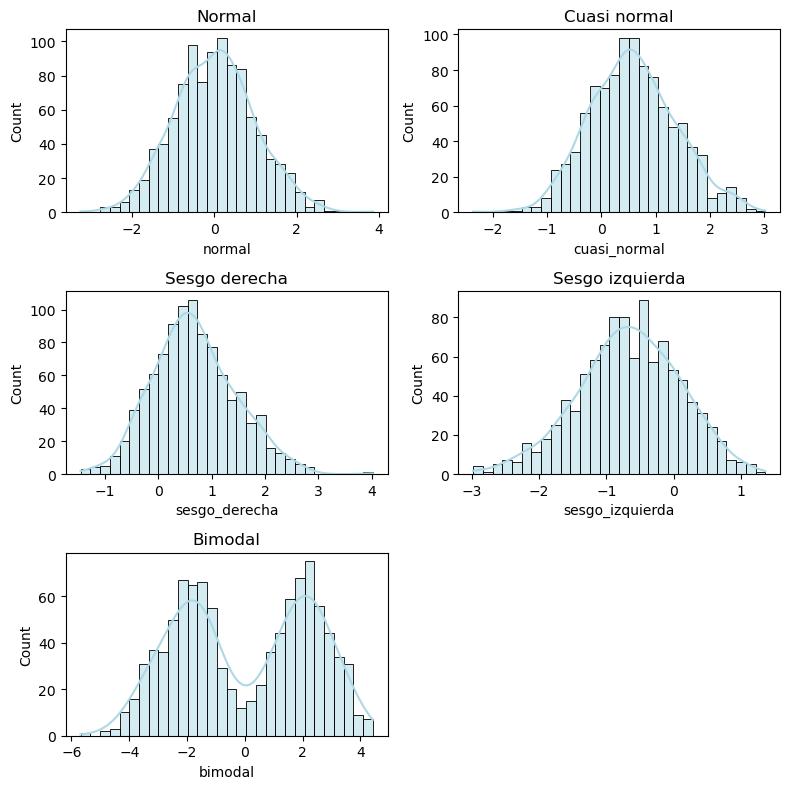

In [35]:
plt.figure(figsize=(8, 8))
for i, column in enumerate(df.columns, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[column], kde=True, bins=30, color='lightblue') #kernel density esti
    plt.title(column.replace("_", " ").capitalize())
plt.tight_layout()

Gráficos Q-Q

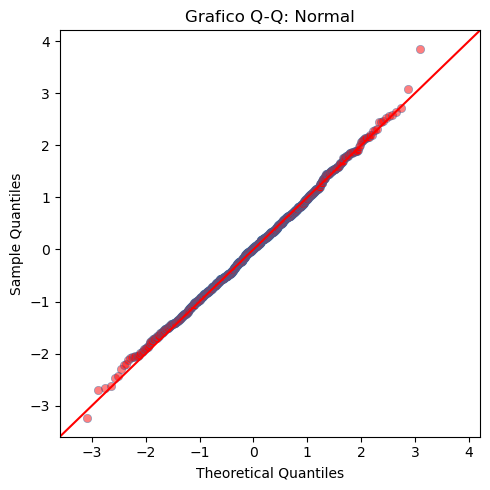

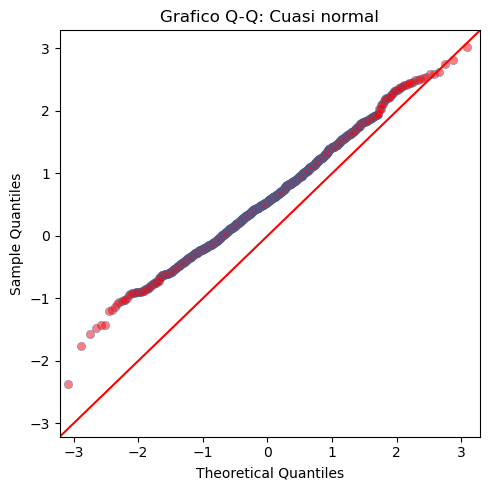

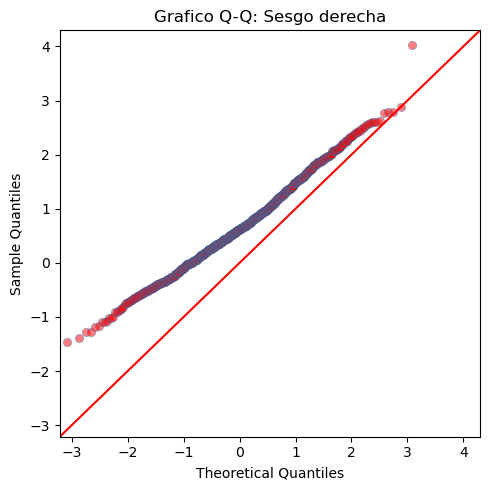

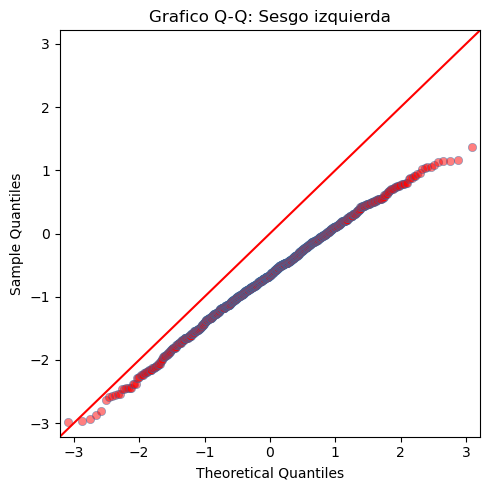

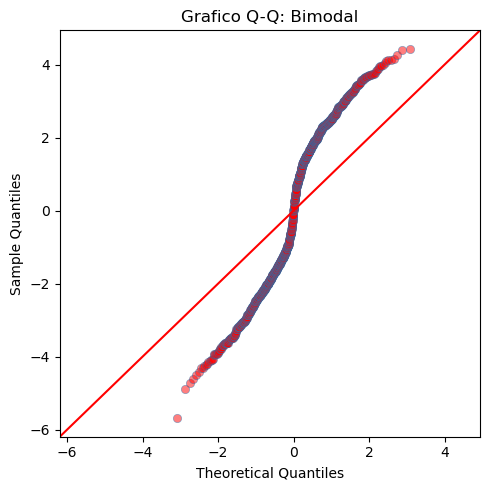

In [36]:
for i, column in enumerate(df.columns, 1):
    fit, ax=plt.subplots(figsize=(5,5))
    sm.qqplot(df[column], line='45', alpha=0.5, lw=1, color='blue',
             markerfacecolor='red', markeredgewidth=0.5,
             ax=ax)
    plt.title(f'Grafico Q-Q: {column.replace("_", " ").capitalize()}')
    plt.tight_layout()

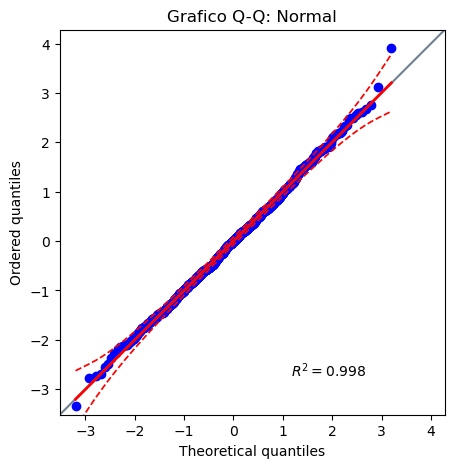

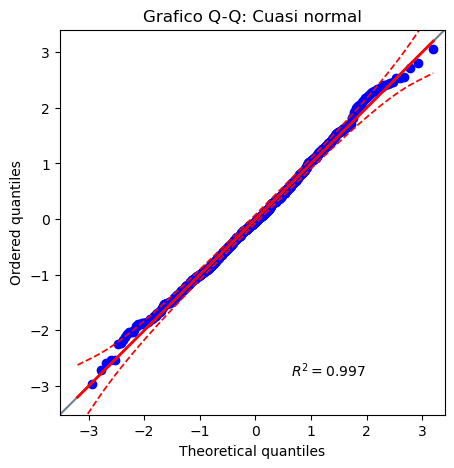

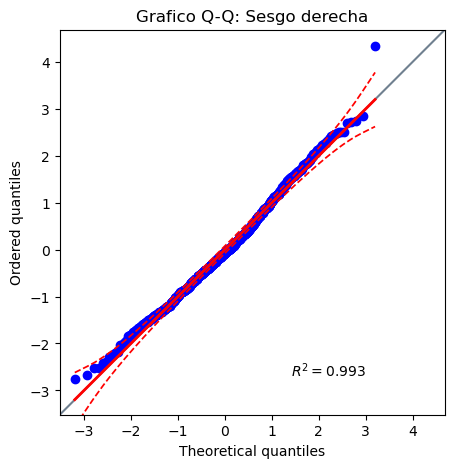

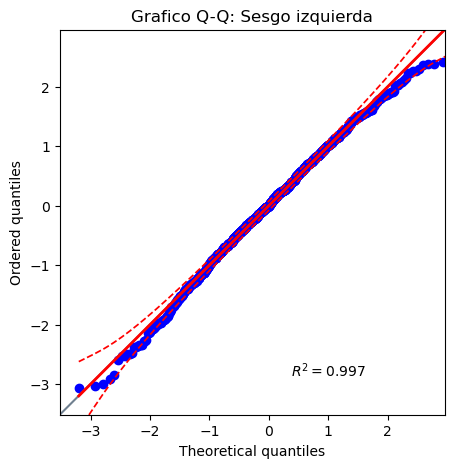

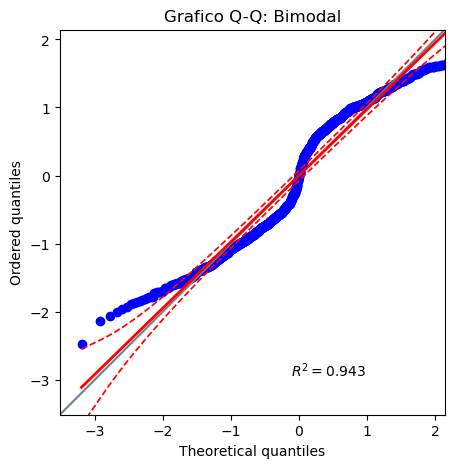

In [37]:
for column in df.columns:
    fig, ax =plt.subplots(figsize=(5,5))
    #confidence es el porcentaje que quieres, recomendablemente es 95%
    pg.qqplot(df[column], dist='norm', confidence=.95, ax=ax)
    ax.set_title(f'Grafico Q-Q: {column.replace('_', ' ').capitalize()}')

Prueba de kolmogorov-smirnov

In [38]:
for column in df.columns:
    D, p_ks = kstest(df[column], 'norm', args=(0,1))

    #imprimir resultados
    print(f'Prueba de kolmogorov-smirnov para: {column}')
    print(f" Estadistica (D) = {D:.4f},p={p_ks:.10f} {'Rechazar H (p<0.05)' if p_ks < 0.05 else 'No se rechaza H (p>=0.05)'}\n")

Prueba de kolmogorov-smirnov para: normal
 Estadistica (D) = 0.0173,p=0.9196626608 No se rechaza H (p>=0.05)

Prueba de kolmogorov-smirnov para: cuasi_normal
 Estadistica (D) = 0.2665,p=0.0000000000 Rechazar H (p<0.05)

Prueba de kolmogorov-smirnov para: sesgo_derecha
 Estadistica (D) = 0.3167,p=0.0000000000 Rechazar H (p<0.05)

Prueba de kolmogorov-smirnov para: sesgo_izquierda
 Estadistica (D) = 0.3094,p=0.0000000000 Rechazar H (p<0.05)

Prueba de kolmogorov-smirnov para: bimodal
 Estadistica (D) = 0.3071,p=0.0000000000 Rechazar H (p<0.05)



In [41]:
for column in df.columns:
    W, p_shapiro = shapiro(df[column])
    
    #imprimir resultados
    print(f'Prueba de shapiro-wilk para: {column}')
    print(f" Estadistica (W) = {W:.4f},p={p_shapiro:.10f} {'Rechazar H (p<0.05)' if p_shapiro < 0.05 else 'No se rechaza H (p>=0.05)'}\n")

Prueba de shapiro-wilk para: normal
 Estadistica (W) = 0.9986,p=0.6272578290 No se rechaza H (p>=0.05)

Prueba de shapiro-wilk para: cuasi_normal
 Estadistica (W) = 0.9968,p=0.0412223172 Rechazar H (p<0.05)

Prueba de shapiro-wilk para: sesgo_derecha
 Estadistica (W) = 0.9935,p=0.0002412940 Rechazar H (p<0.05)

Prueba de shapiro-wilk para: sesgo_izquierda
 Estadistica (W) = 0.9962,p=0.0158835142 Rechazar H (p<0.05)

Prueba de shapiro-wilk para: bimodal
 Estadistica (W) = 0.9418,p=0.0000000000 Rechazar H (p<0.05)



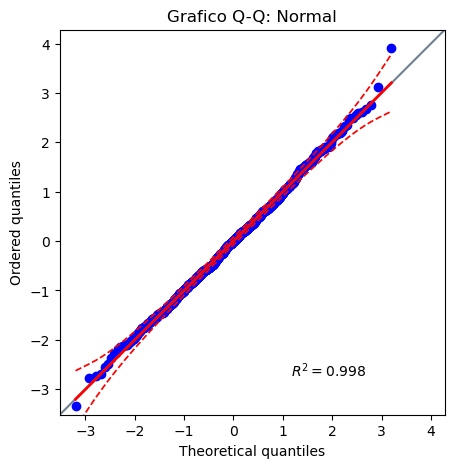

Prueba estadisticas para: normal
 Kolmogorov Estadistica (D) = 0.0173,p=0.9196626608 No se rechaza H (p>=0.05)

 Shapiro Estadistica (W) = 0.9986,p=0.6272578290 No se rechaza H (p>=0.05)



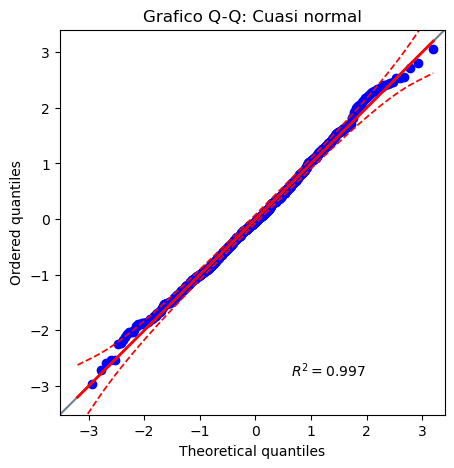

Prueba estadisticas para: cuasi_normal
 Kolmogorov Estadistica (D) = 0.2665,p=0.0000000000 Rechazar H (p<0.05)

 Shapiro Estadistica (W) = 0.9968,p=0.0412223172 Rechazar H (p<0.05)



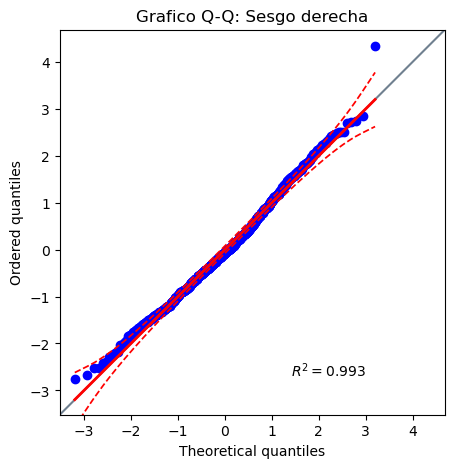

Prueba estadisticas para: sesgo_derecha
 Kolmogorov Estadistica (D) = 0.3167,p=0.0000000000 Rechazar H (p<0.05)

 Shapiro Estadistica (W) = 0.9935,p=0.0002412940 Rechazar H (p<0.05)



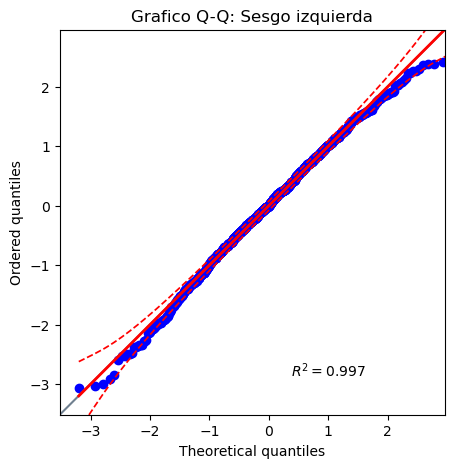

Prueba estadisticas para: sesgo_izquierda
 Kolmogorov Estadistica (D) = 0.3094,p=0.0000000000 Rechazar H (p<0.05)

 Shapiro Estadistica (W) = 0.9962,p=0.0158835142 Rechazar H (p<0.05)



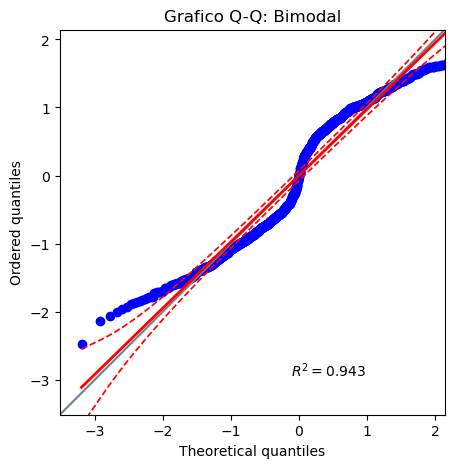

Prueba estadisticas para: bimodal
 Kolmogorov Estadistica (D) = 0.3071,p=0.0000000000 Rechazar H (p<0.05)

 Shapiro Estadistica (W) = 0.9418,p=0.0000000000 Rechazar H (p<0.05)



In [42]:
for column in df.columns:
    fig,ax = plt.subplots(figsize=(5,5))
    pg.qqplot(df[column], dist='norm', confidence=.95, ax=ax)
    ax.set_title(f'Grafico Q-Q: {column.replace('_',' ').capitalize()}')
    plt.show()

    #Pruebas
    D, p_ks = kstest(df[column], 'norm', args=(0,1))
    W, p_shapiro = shapiro(df[column])

    #Imprimir resultado
    print(f'Prueba estadisticas para: {column}')
    print(f" Kolmogorov Estadistica (D) = {D:.4f},p={p_ks:.10f} {'Rechazar H (p<0.05)' if p_ks < 0.05 else 'No se rechaza H (p>=0.05)'}\n")
    print(f" Shapiro Estadistica (W) = {W:.4f},p={p_shapiro:.10f} {'Rechazar H (p<0.05)' if p_shapiro < 0.05 else 'No se rechaza H (p>=0.05)'}\n")
